# Project Introduction

This notebook analyzes a randomized survey experiment on tipping behavior.
* Participants were presented with a standardized restaurant scenario (a $16 meal with professional service) and asked to choose a tip from preset percentage options.
* The key experimental manipulation is the default framing of the tip options: the control condition centers around 15%, while the treatment condition shifts the default upward to 18%.
* The objective is to estimate how increasing the default tip level affects tipping choices.
* QID1 - QID10: Control Group
* QID13 - QID20: Treatment Group


### Data Dictionary

| Variable Name | Description |
|---|---|
| StartDate | Start Date |
| EndDate | End Date |
| Status | Response Type |
| IPAddress | IP Address |
| Progress | Progress |
| Duration (in seconds) | Duration (in seconds) |
| Finished | Finished |
| RecordedDate | Recorded Date |
| ResponseId | Response ID |
| RecipientLastName | Recipient Last Name |
| RecipientFirstName | Recipient First Name |
| RecipientEmail | Recipient Email |
| ExternalReference | External Data Reference |
| LocationLatitude | Location Latitude |
| LocationLongitude | Location Longitude |
| DistributionChannel | Distribution Channel |
| UserLanguage | User Language |
| QID1 | How much would you tip? - Selected Choice |
| QID1_4_TEXT | How much would you tip? - Customise - Text |
| QID2 | How old are you?  |
| QID3 | What is your race? - Selected Choice |
| QID3_6_TEXT | What is your race? - Other - Text |
| QID4 | How long have you lived in the US? |
| QID5 | Are you working or have you ever worked in the service industry? |
| QID6 | How often do you dine in at a restaurant? |
| QID8 | Tipping plays a role in how restaurant workers are compensated. |
| QID10 | Restaurant staff compensation should primarily come from wages paid by employers. |
| QID13 | How much would you tip? - Selected Choice |
| QID13_4_TEXT | How much would you tip? - Customise - Text |
| Q23 | How old are you? |
| QID15 | What is your race? - Selected Choice |
| QID15_6_TEXT | What is your race? - Other - Text |
| QID16 | How long have you lived in the US? |
| QID17 | Are you working or have you ever worked in the service industry? |
| QID18 | How often do you dine in at a restaurant? |
| QID19 | Tipping plays a role in how restaurant workers are compensated. |
| QID20 | Restaurant staff compensation should primarily come from wages paid by employers. |

In [50]:
%%capture
# install the package used for statistical analyses
!pip install pingouin
!pip install Stargazer

import pandas as pd

# Please upload the csv file in the colab workplace!!!
# Read the csv files
df = pd.read_csv('/content/Dining Experience Simulation Study_March 3, 2026_12.21.csv')
print(df.columns)

# Delete the metadata rows (first two rows) and reset the index.
df = df.iloc[2:].copy()
df = df.reset_index(drop=True)

# Preprocessing

In [51]:
import numpy as np
import pandas as pd

# Delete the rows where {Status = "Survey Preview"}
df = df[df['Status'] != 'Survey Preview'].copy()

# Delete the rows where {Progress != 100}
df = df[df['Progress'] == '100'].copy()
df = df.reset_index(drop=True)

# Print the number of survey results after cleaning
print(f"Number of survey results after cleaning: {len(df)}")



# Create Treatment indicator in original df
df["Treatment"] = np.where(df["QID13"].notna(), 1,
                    np.where(df["QID1"].notna(), 0, np.nan))

# Create new merged dataframe
df_res = pd.DataFrame(index=df.index)

df_res["Treatment"] = df["Treatment"]

# Merge control (QID1–QID10) and treatment (QID13–QID20) into QID1–QID10 structure

df_res["QID1"] = df["QID1"].combine_first(df["QID13"])
df_res["QID1_4_TEXT"] = df["QID1_4_TEXT"].combine_first(df["QID13_4_TEXT"])
df_res["QID2"] = df["QID2"].combine_first(df["Q23"])
df_res["QID3"] = df["QID3"].combine_first(df["QID15"])
df_res["QID3_6_TEXT"] = df["QID3_6_TEXT"].combine_first(df["QID15_6_TEXT"])
df_res["QID4"] = df["QID4"].combine_first(df["QID16"])
df_res["QID5"] = df["QID5"].combine_first(df["QID17"])
df_res["QID6"] = df["QID6"].combine_first(df["QID18"])
df_res["QID8"] = df["QID8"].combine_first(df["QID19"])
df_res["QID10"] = df["QID10"].combine_first(df["QID20"])
print(len(df_res))
df_res.head(10)

Number of survey results after cleaning: 81
81


,Treatment,QID1,QID1_4_TEXT,QID2,QID3,QID3_6_TEXT,QID4,QID5,QID6,QID8,QID10
0,0.0,15% ($2.40). Total: $18.40,NaN,18 - 25,Asian,NaN,<1 year,Yes,1-3 times a week,3,5- Strongly Agree
1,0.0,15% ($2.40). Total: $18.40,NaN,18 - 25,Asian,NaN,<1 year,No,1-3 times a week,4,4
2,0.0,15% ($2.40). Total: $18.40,NaN,Below 18,Asian,NaN,<1 year,Yes,1-3 times a week,1- Strongly Disagree,5- Strongly Agree
3,0.0,15% ($2.40). Total: $18.40,NaN,18 - 25,Asian,NaN,5+ years,No,4-7 times a week,4,1- Strongly Disagree
4,0.0,18% ($2.88). Total: $18.80,NaN,18 - 25,Asian,NaN,1–5 years,No,1-3 times a week,5- Strongly Agree,3
5,1.0,Customise,1.6,25 - 40,Asian,NaN,1–5 years,Yes,1-3 times a week,3,5- Strongly Agree
6,0.0,20% ($3.20). Total: $19.20,NaN,18 - 25,Asian,NaN,5+ years,Yes,More than 7 times a week,5- Strongly Agree,5- Strongly Agree
7,1.0,25% ($4.00). Total: $20.00,NaN,18 - 25,Asian,NaN,1–5 years,Yes,I almost never go to restaurants.,1- Strongly Disagree,2
8,0.0,15% ($2.40). Total: $18.40,NaN,25 - 40,Asian,NaN,1–5 years,No,1-3 times a week,3,5- Strongly Agree
9,0.0,15% ($2.40). Total: $18.40,NaN,25 - 40,Asian,NaN,5+ years,No,1-3 times a week,3,3


# EDA

## Survey Duration(Analyze)

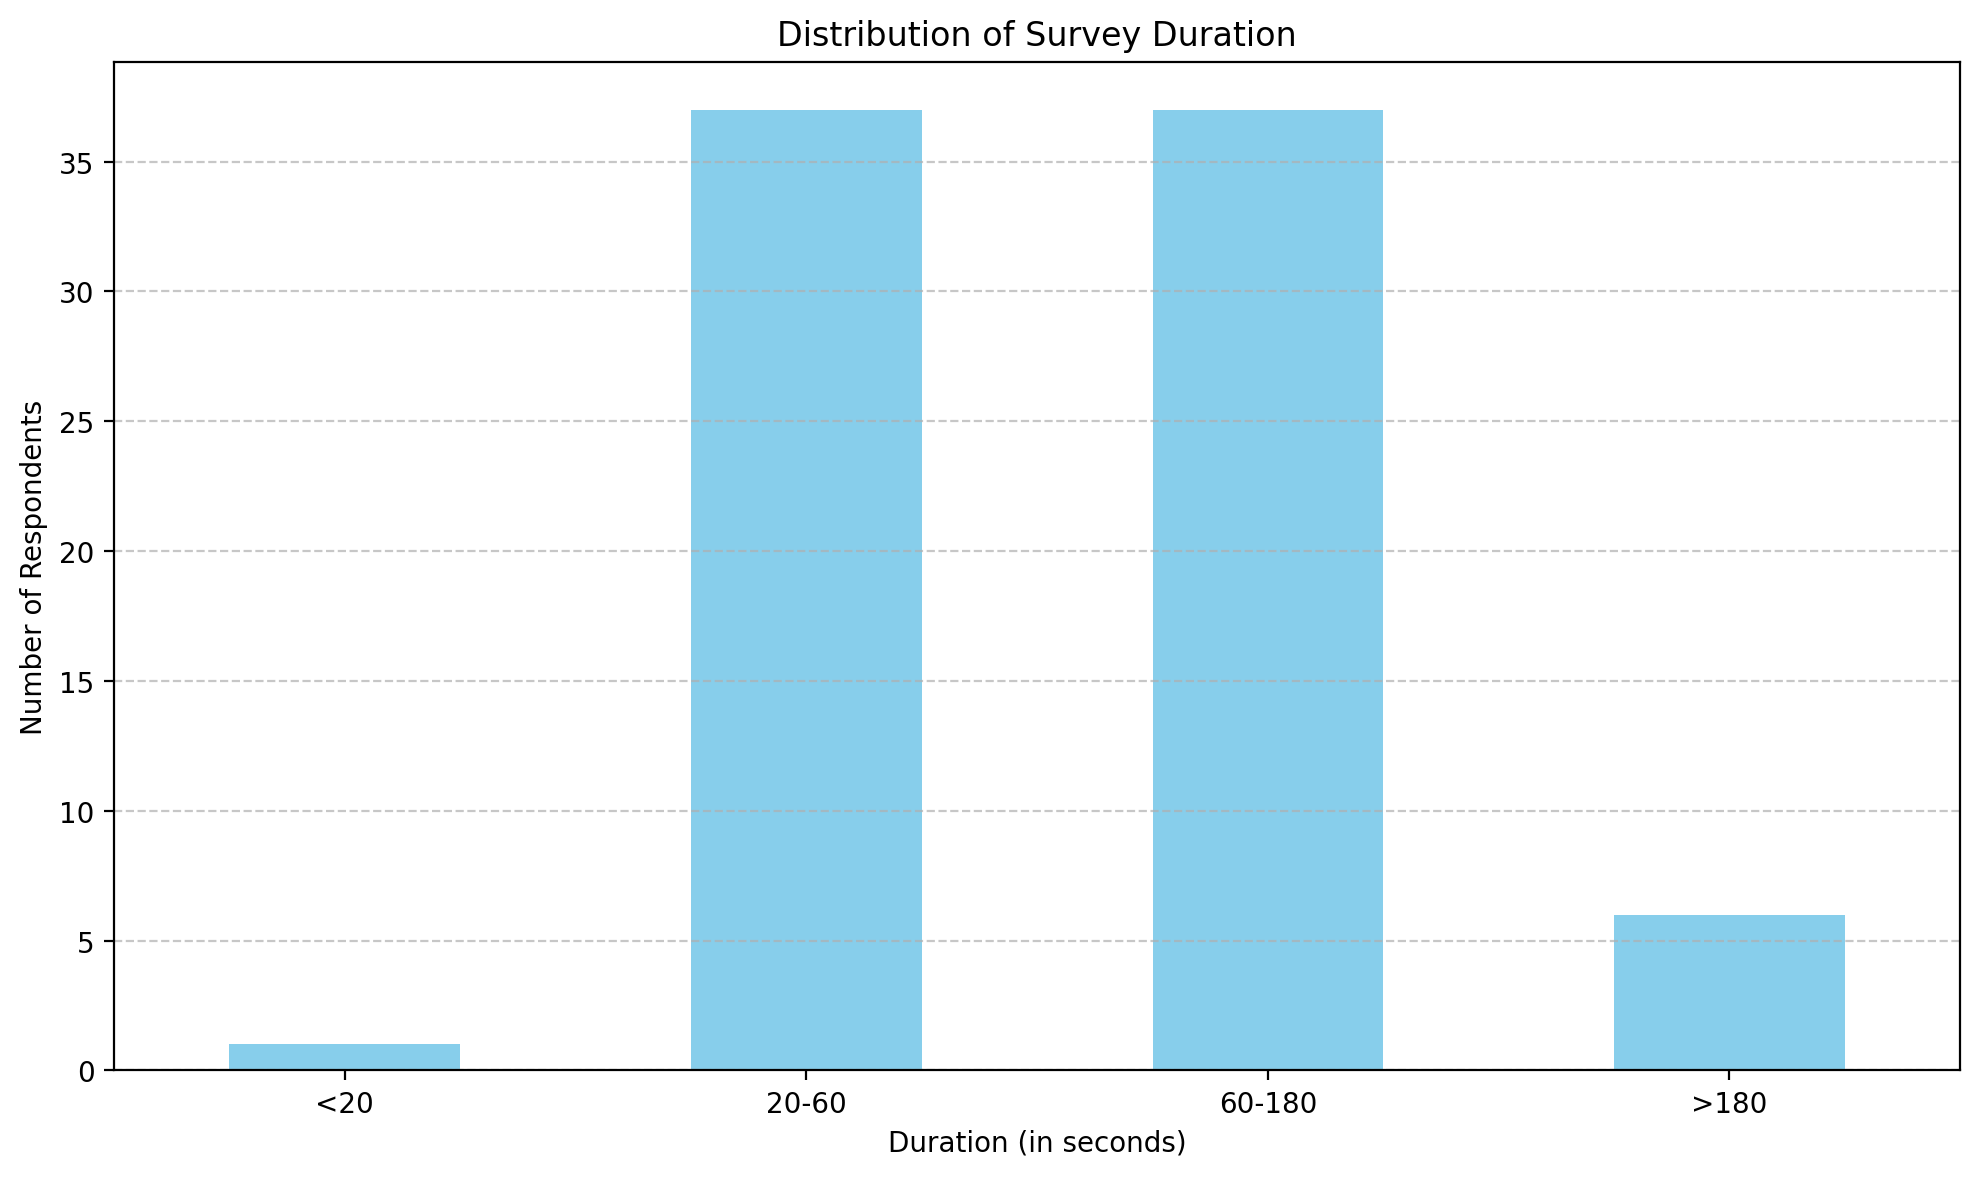

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Convert 'Duration (in seconds)' to numeric, handling potential non-numeric rows
duration = pd.to_numeric(df['Duration (in seconds)'], errors='coerce')

# Drop NaN values that resulted from conversion (e.g., header rows)
duration = duration.dropna()

# Define the bins for the categories
bins = [0, 20, 60, 180, np.inf]
labels = ['<20', '20-60', '60-180', '>180']

# Categorize the durations into the defined bins
df['duration_category'] = pd.cut(duration, bins=bins, labels=labels, right=False)

# Calculate the distribution of each category
distribution = df['duration_category'].value_counts().reindex(labels)

# Plot the distribution
plt.figure(figsize=(10, 6))
distribution.plot(kind='bar', color='skyblue')
plt.title('Distribution of Survey Duration')
plt.xlabel('Duration (in seconds)')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Demographic, Dining Behavior, and Tipping Attitude(Analyze)

/tmp/ipykernel_1018/4014002229.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_res[col].dropna(), order=value_counts.index, palette='viridis')
/tmp/ipykernel_1018/4014002229.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_res[col].dropna(), order=value_counts.index, palette='viridis')
/tmp/ipykernel_1018/4014002229.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=df_res[col].dropna(), order=value_counts.index, palette='viridis')
/tmp/ipykernel_1018/4014002229.py:30: FutureWarning: 

Passing `pal

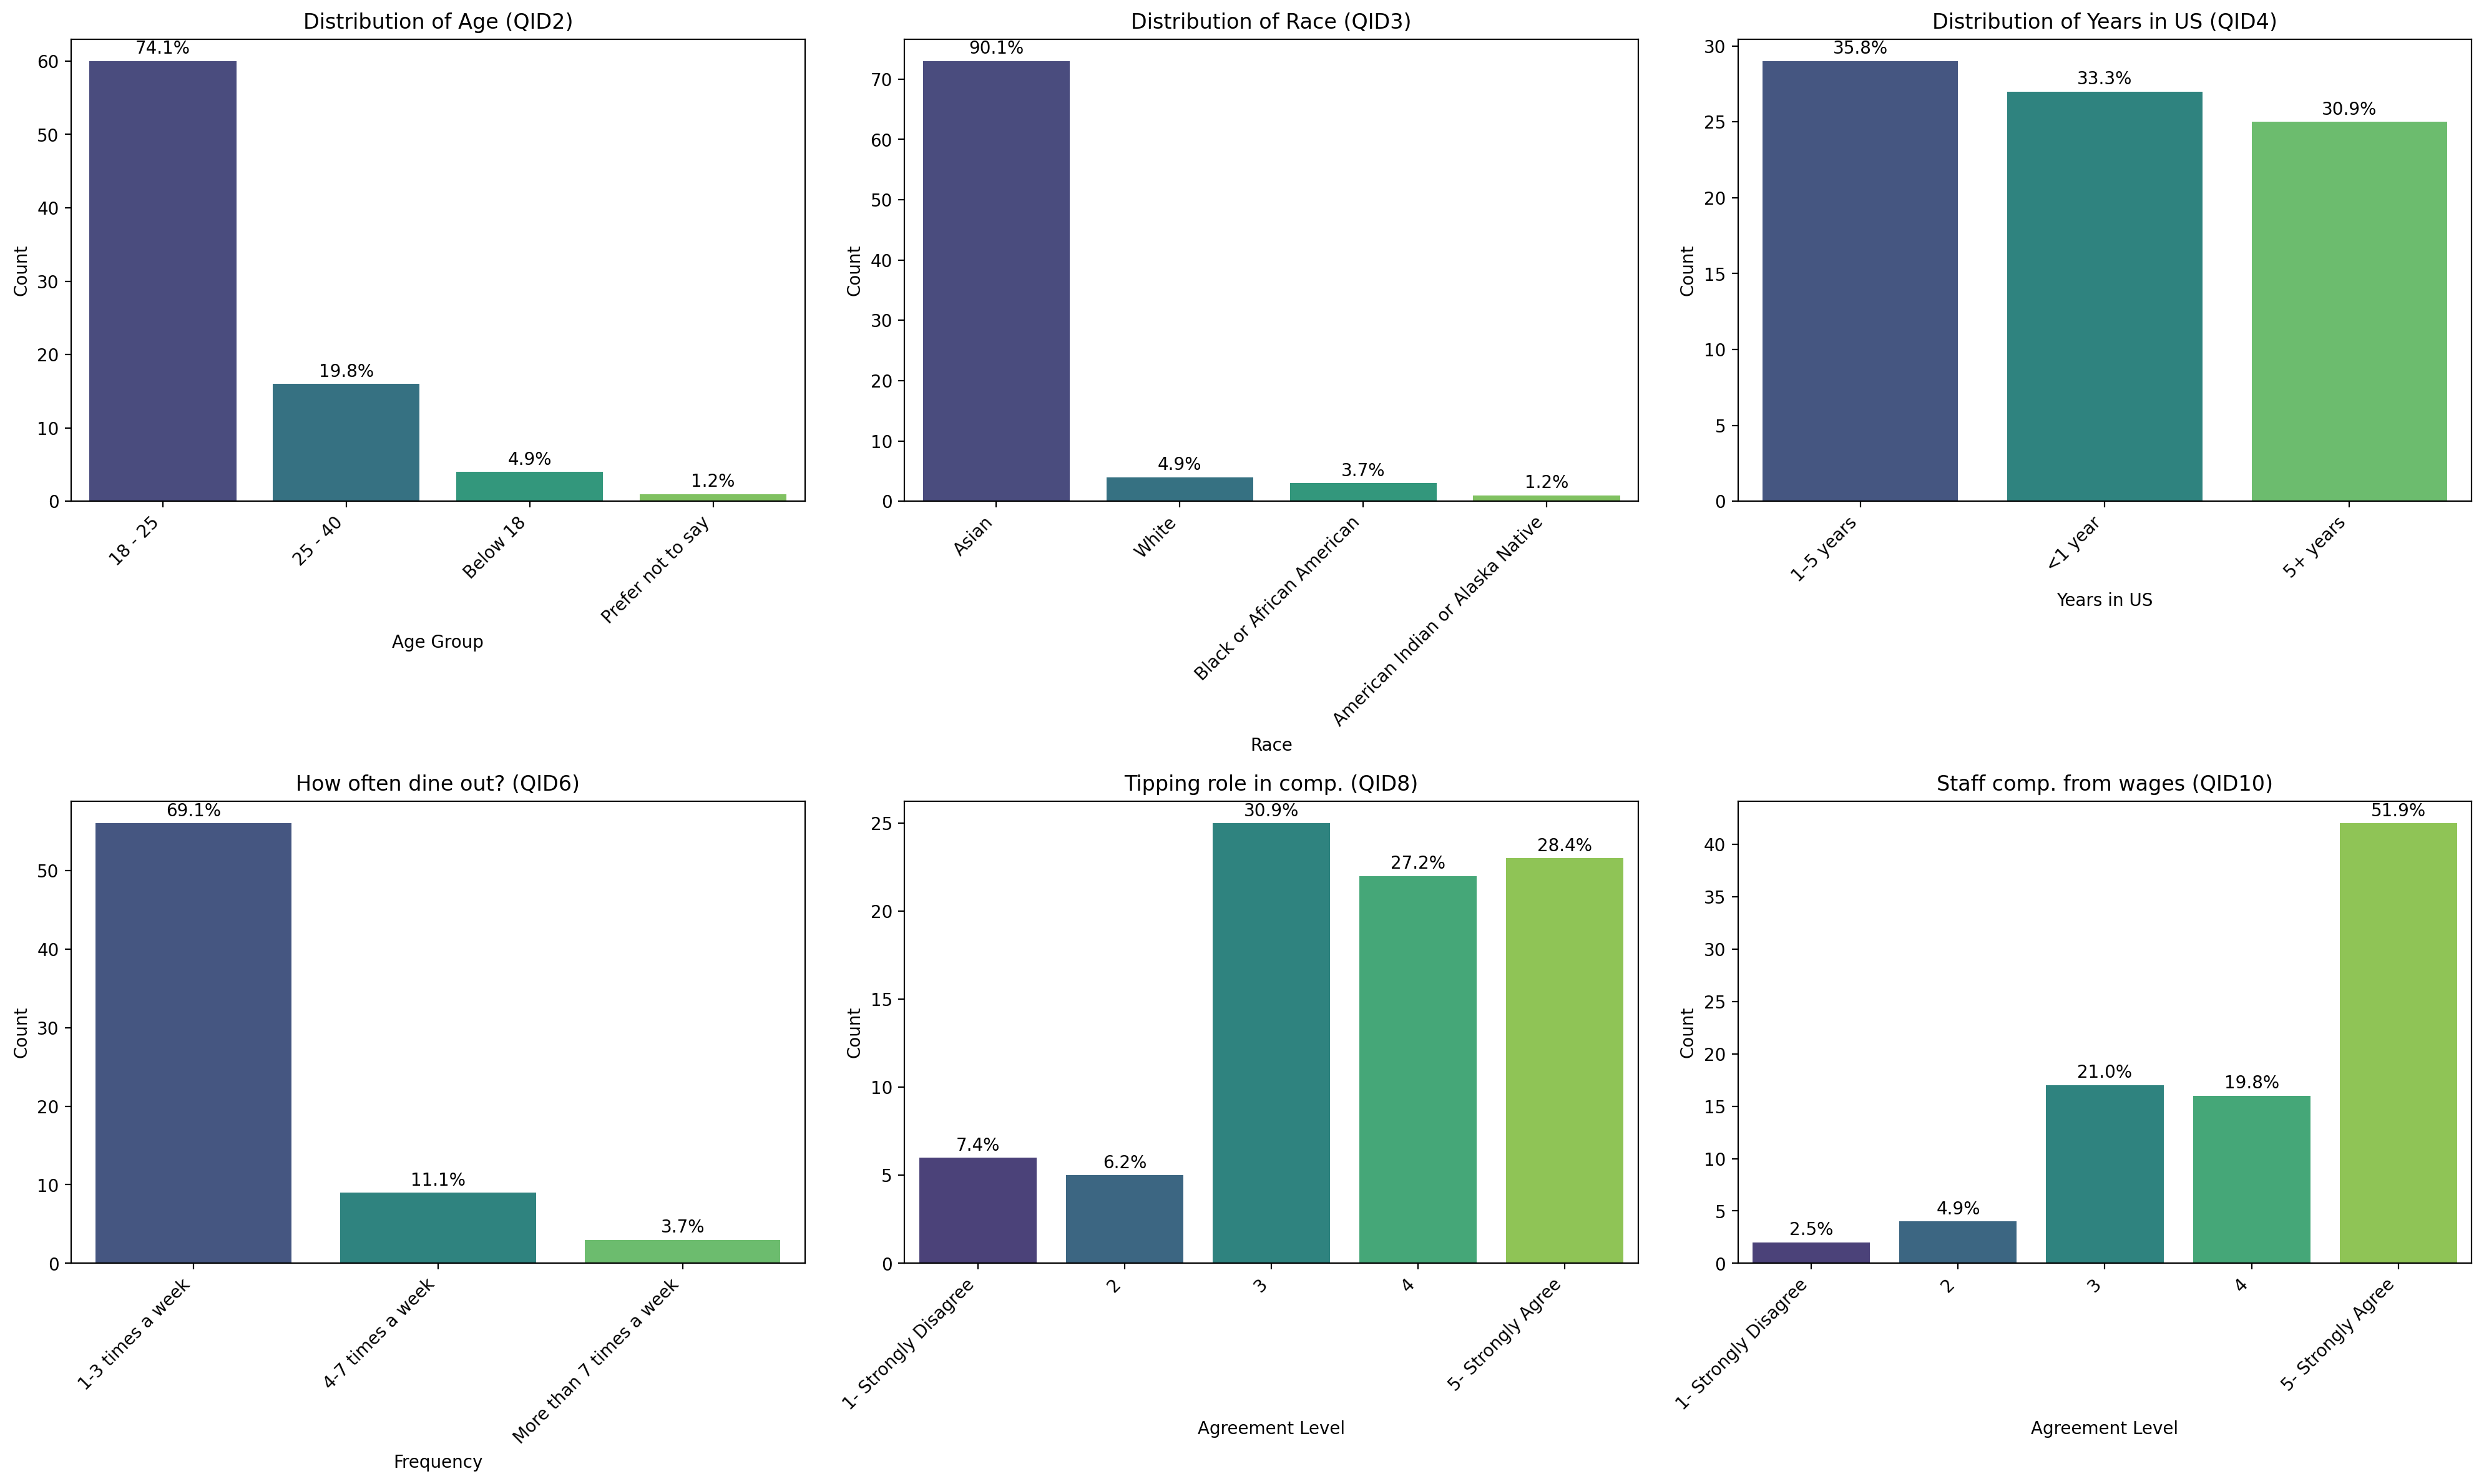

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define the columns for which bar charts are requested
columns_to_plot = ['QID2', 'QID3', 'QID4', 'QID6', 'QID8', 'QID10']

plt.figure(figsize=(20, 12)) # Adjusted figure size for 2 rows of 3 plots

for i, col in enumerate(columns_to_plot):
    plt.subplot(2, 3, i + 1) # 2 rows, 3 columns

    # Calculate value counts and percentages
    value_counts = df_res[col].value_counts(dropna=True)
    percentages = df_res[col].value_counts(normalize=True, dropna=True) * 100

    # Ensure percentages are ordered consistently with value_counts.index
    percentages_ordered = percentages.reindex(value_counts.index)

    custom_order = None
    if col == 'QID6':
        custom_order = ['Never go', 'Less than once a month', '1-3 times a month', '1-3 times a week', '4-7 times a week', 'More than 7 times a week']
    elif col == 'QID8' or col == 'QID10':
        custom_order = ['1- Strongly Disagree', '2', '3', '4', '5- Strongly Agree']

    if custom_order:
        # Reindex value_counts and percentages for consistent ordering
        ordered_values = value_counts.reindex(custom_order).dropna()
        ordered_percentages = percentages.reindex(custom_order).dropna()
        ax = sns.countplot(x=df_res[col].dropna(), order=ordered_values.index, palette='viridis')
    else:
        ax = sns.countplot(x=df_res[col].dropna(), order=value_counts.index, palette='viridis')
        ordered_percentages = percentages_ordered # Use original ordered percentages if no custom order

    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability

    # Set title and labels based on the column
    if col == 'QID2':
        plt.title(f'Distribution of Age (QID2)')
        plt.xlabel('Age Group')
        plt.ylabel('Count')
    elif col == 'QID3':
        plt.title(f'Distribution of Race (QID3)')
        plt.xlabel('Race')
        plt.ylabel('Count')
    elif col == 'QID4':
        plt.title(f'Distribution of Years in US (QID4)')
        plt.xlabel('Years in US')
        plt.ylabel('Count')
    elif col == 'QID6':
        plt.title(f'How often dine out? (QID6)')
        plt.xlabel('Frequency')
        plt.ylabel('Count')
    elif col == 'QID8':
        plt.title(f'Tipping role in comp. (QID8)')
        plt.xlabel('Agreement Level')
        plt.ylabel('Count')
    elif col == 'QID10':
        plt.title(f'Staff comp. from wages (QID10)')
        plt.xlabel('Agreement Level')
        plt.ylabel('Count')

    # Add percentage labels
    for idx, p in enumerate(ax.patches):
        height = p.get_height()
        x_center = p.get_x() + p.get_width() / 2
        # Use ordered_values for custom_order cases, otherwise fallback to value_counts
        current_value_counts_index = ordered_values.index if custom_order else value_counts.index
        category_label = current_value_counts_index[idx]
        percentage = ordered_percentages[category_label]
        ax.annotate(f'{percentage:.1f}%', (x_center, height), ha='center', va='bottom', xytext=(0, 2), textcoords='offset points') # Decreased xytext y-offset to 2 for lower placement

plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

# Convert QID8 and QID10 to numeric values
# The values are like '1- Strongly Disagree', '2', '3', '4', '5- Strongly Agree'
# We need to extract the numerical part
df_res['QID8_numeric'] = df_res['QID8'].astype(str).str[0].astype(float)
df_res['QID10_numeric'] = df_res['QID10'].astype(str).str[0].astype(float)

# Calculate the Pearson correlation between QID8_numeric and QID10_numeric
correlation = df_res['QID8_numeric'].corr(df_res['QID10_numeric'])

print(f"Correlation between QID8 (Tipping plays a role in compensation) and QID10 (Staff compensation from wages): {correlation:.3f}")

Correlation between QID8 (Tipping plays a role in compensation) and QID10 (Staff compensation from wages): 0.040


# Randomization Check

## Treatment vs Control Group Size(Analyze)

In [55]:
from scipy.stats import chisquare
import pandas as pd

import pandas as pd
from statsmodels.stats.proportion import proportion_confint

# Recalculate the number of respondents in each group (from previous steps)
treatment_counts = df_res['Treatment'].value_counts().reindex([0.0, 1.0], fill_value=0)
total_respondents = len(df_res)

# Extract counts for control (0.0) and treatment (1.0)
control_count = treatment_counts.get(0.0, 0)
treatment_count = treatment_counts.get(1.0, 0)

# Calculate proportions
control_proportion = control_count / total_respondents
treatment_proportion = treatment_count / total_respondents

# Calculate the 95% confidence interval for the control group proportion
# Using the 'wilson' method which is robust for proportions
conf_int_low, conf_int_high = proportion_confint(control_count, total_respondents, alpha=0.05, method='wilson')

print(f"Total respondents: {total_respondents}")
print(f"\nControl Group (Treatment = 0):")
print(f"  Number of respondents: {control_count}")
print(f"  Percentage: {control_proportion:.2%}")
print(f"  95% Confidence Interval for proportion: ({conf_int_low:.3f}, {conf_int_high:.3f})")

print(f"\nTreatment Group (Treatment = 1):")
print(f"  Number of respondents: {treatment_count}")
print(f"  Percentage: {treatment_proportion:.2%}")

# The confidence interval for the treatment group can be inferred as (1 - conf_int_high, 1 - conf_int_low) for control
print(f"  95% Confidence Interval for proportion: ({1 - conf_int_high:.3f}, {1 - conf_int_low:.3f})")

# Calculate the number of respondents in each group
treatment_counts = df_res['Treatment'].value_counts().reindex([0.0, 1.0], fill_value=0)

# Get the P-value for group sizes
total_respondents = len(df_res)
expected_counts = [total_respondents / 2, total_respondents / 2]
_, p_value = chisquare(f_obs=treatment_counts, f_exp=expected_counts)

print(f"\nThe p-value for comparing treatment vs control group sizes is: {p_value:.3f}")

Total respondents: 81

Control Group (Treatment = 0):
  Number of respondents: 47
  Percentage: 58.02%
  95% Confidence Interval for proportion: (0.472, 0.682)

Treatment Group (Treatment = 1):
  Number of respondents: 34
  Percentage: 41.98%
  95% Confidence Interval for proportion: (0.318, 0.528)

The p-value for comparing treatment vs control group sizes is: 0.149


## Age and Years Live in the US(Analyze)

In [56]:
from scipy.stats import chi2_contingency
import pandas as pd

# Create a contingency table of 'QID2' (age groups) and 'Treatment'
contingency_table_age = pd.crosstab(df_res['QID2'], df_res['Treatment'])

print("Contingency Table (Age vs. Treatment):\n", contingency_table_age)

# Perform the chi-square test for independence
chi2_age, p_value_age, dof_age, expected_age = chi2_contingency(contingency_table_age)

# Print the results
print(f"\nChi-square statistic for Age: {chi2_age:.3f}")
print(f"P-value for Age: {p_value_age:.3f}")

Contingency Table (Age vs. Treatment):
 Treatment          0.0  1.0
QID2                       
18 - 25             35   25
25 - 40              9    7
Below 18             2    2
Prefer not to say    1    0

Chi-square statistic for Age: 0.852
P-value for Age: 0.837


In [57]:
from scipy.stats import chi2_contingency

# Create a contingency table of 'QID4' (years in US) and 'Treatment'
contingency_table_years = pd.crosstab(df_res['QID4'], df_res['Treatment'])

print("Contingency Table (Years in US vs. Treatment):\n", contingency_table_years)

# Perform the chi-square test for independence
chi2_years, p_value_years, dof_years, expected_years = chi2_contingency(contingency_table_years)

# Print the results
print(f"\nChi-square statistic for Years in US: {chi2_years:.3f}")
print(f"P-value for Years in US: {p_value_years:.3f}")

Contingency Table (Years in US vs. Treatment):
 Treatment  0.0  1.0
QID4               
1–5 years   18   11
5+ years    16    9
<1 year     13   14

Chi-square statistic for Years in US: 1.643
P-value for Years in US: 0.440


# Regression for ATE

## Build the Tip_Percent feature

In [58]:
df_res['QID1_4_TEXT'].unique()

array([nan, '1.6', '0', '10%', 'I tip 15% and I’m 25 yrs old!', '0% ($0)',
       '18.00', '1', '2', '25%', '15%'], dtype=object)

In [59]:
import numpy as np
import re

PRICE = 16.0  # food price

def custom_to_pct_price_rule(x, price=PRICE):
    # treat NaN properly
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return np.nan

    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return np.nan

    # If it explicitly contains a percent sign, use that percent
    m = re.search(r'(\d+(?:\.\d+)?)\s*%', s)
    if m:
        return float(m.group(1)) / 100.0

    # If it clearly indicates $0, interpret as 0%
    if re.search(r'\$\s*0\b', s) or re.fullmatch(r'0(?:\.0+)?', s):
        return 0.0

    # Extract first number from the string
    m = re.search(r'(\d+(?:\.\d+)?)', s)
    if not m:
        return np.nan
    val = float(m.group(1))

    # Your rule: if it's a small number (0 to 5), treat it as dollars and divide by $16
    if 0 < val <= 5:
        return val / price

    # Otherwise treat it as a percent number (e.g., 18.00 means 18%)
    if 5 < val <= 100:
        return val / 100.0

    return np.nan

df_res["QID1_4_PCT"] = df_res["QID1_4_TEXT"].apply(custom_to_pct_price_rule)

# quick validation on uniques
df_res[["QID1_4_TEXT", "QID1_4_PCT"]].drop_duplicates().sort_values("QID1_4_TEXT", key=lambda c: c.astype(str))

,QID1_4_TEXT,QID1_4_PCT
18,0,0.0000
44,0% ($0),0.0000
56,1,0.0625
5,1.6,0.1000
28,10%,0.1000
74,15%,0.1500
48,18.00,0.1800
58,2,0.1250
68,25%,0.2500
37,I tip 15% and I’m 25 yrs old!,0.1500


In [60]:
from math import nan
import pandas as pd
import re

def get_tip_percent(row):
    # 1) Prioritize QID1_4_PCT if available
    if pd.notna(row["QID1_4_PCT"]):
        return row["QID1_4_PCT"]

    # 2) If QID1_4_PCT is NaN AND QID1 is "Customise", set to 0
    if pd.notna(row["QID1"]) and str(row["QID1"]).strip().lower() == "customise":
        return 0.0

    # 3) Otherwise try to extract percent from QID1 text (e.g., "15% ($2.40)...")
    if pd.notna(row["QID1"]):
        match = re.search(r'(\d{1,2})\s*%', str(row["QID1"]))
        if match:
            return float(match.group(1)) / 100.0

    return nan

df_res["Tip_Percent"] = df_res.apply(get_tip_percent, axis=1)

# Display the relevant columns to verify the new feature
print("First 10 rows of df_res with the new 'Tip_Percent' feature:")
display(df_res[['QID1', 'QID1_4_TEXT', 'QID1_4_PCT', 'Tip_Percent']].head(82))

First 10 rows of df_res with the new 'Tip_Percent' feature:


,QID1,QID1_4_TEXT,QID1_4_PCT,Tip_Percent
0,15% ($2.40). Total: $18.40,NaN,NaN,0.15
1,15% ($2.40). Total: $18.40,NaN,NaN,0.15
2,15% ($2.40). Total: $18.40,NaN,NaN,0.15
3,15% ($2.40). Total: $18.40,NaN,NaN,0.15
4,18% ($2.88). Total: $18.80,NaN,NaN,0.18
...,...,...,...,...
76,18% ($2.88). Total: $18.80,NaN,NaN,0.18
77,18% ($2.88). Total: $18.80,NaN,NaN,0.18
78,15% ($2.40). Total: $18.40,NaN,NaN,0.15
79,15% ($2.40). Total: $18.40,NaN,NaN,0.15


## Simple Linear Regression(Analyze)

Instead of using `smf.ols`, we use [`pf.feols`](https://py-econometrics.github.io/pyfixest/reference/estimation.estimation.feols.html) from package [`pyfixest`](https://py-econometrics.github.io/pyfixest/quickstart.html)\. In addition to estimating regular regression, this function will allow us to estimate an Instrumental Variables Regression to estimate the CACE.

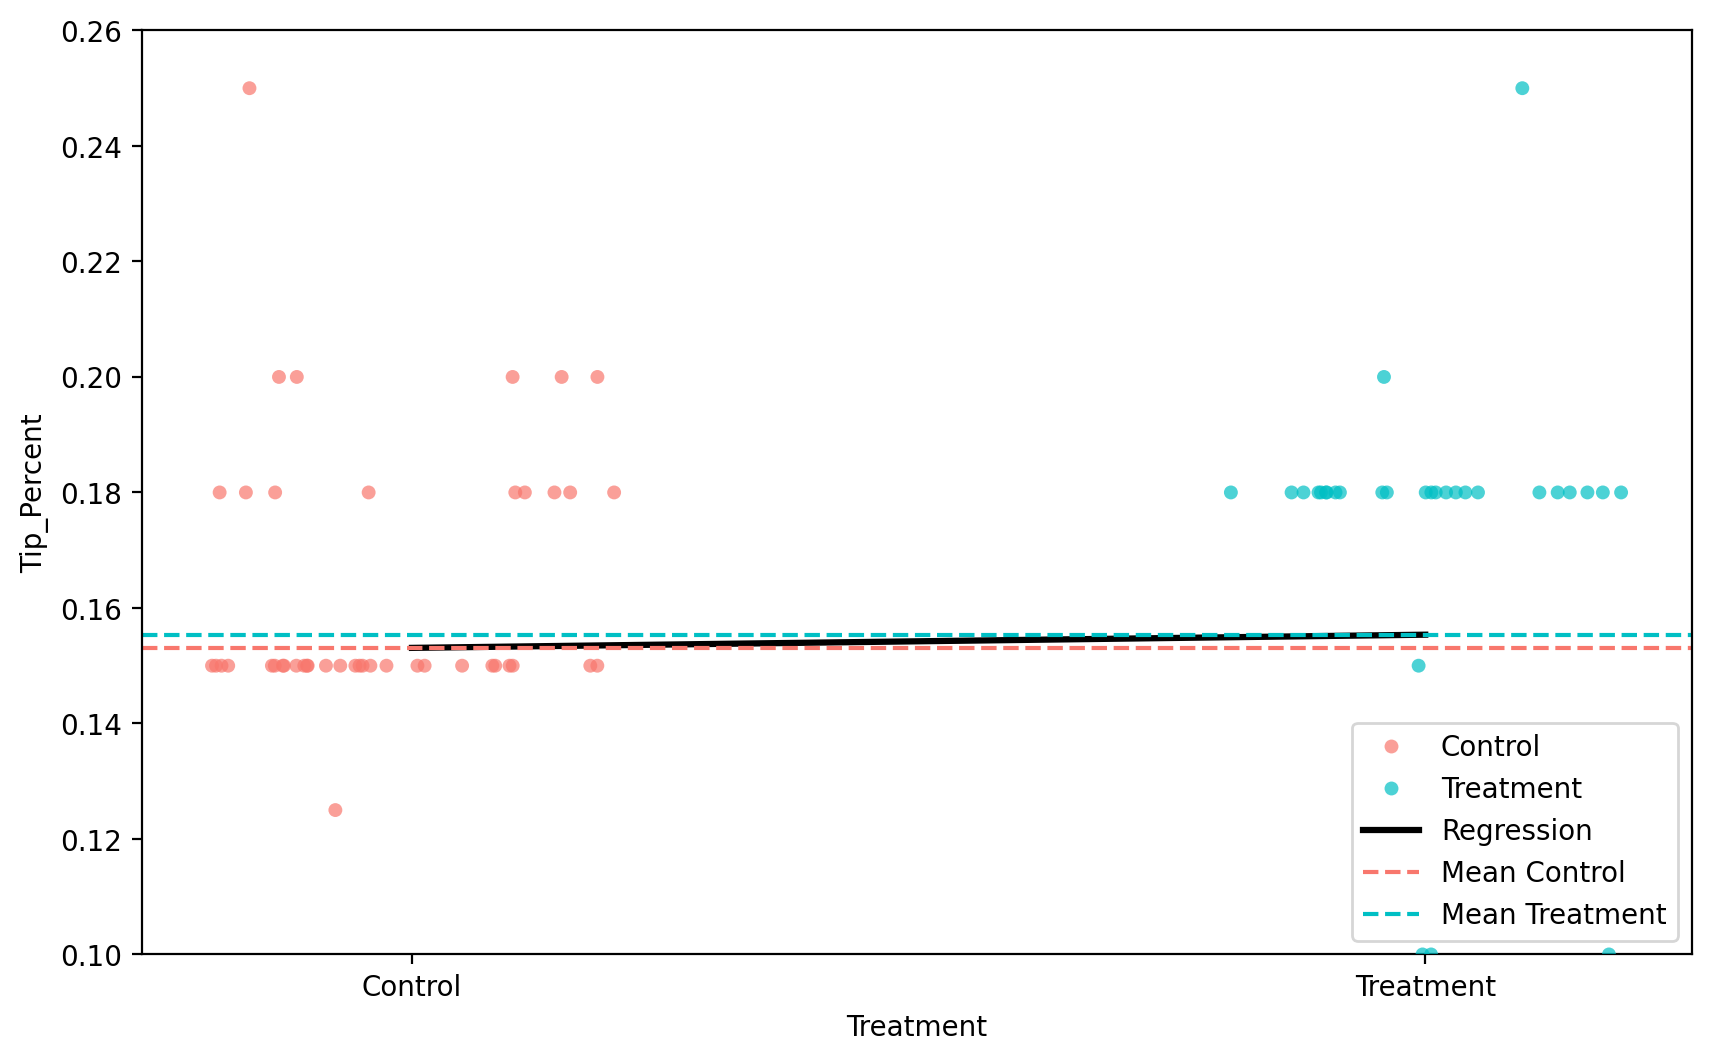

In [61]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Assumes:
# - df_res has columns: Treatment (0/1) and Tip_Percent (numeric, e.g., 0.15 for 15%)
# - Tip_Percent may contain NaNs

data = df_res.dropna(subset=["Treatment", "Tip_Percent"]).copy()

# nicer labels for hue/legend
data["treatment_factor"] = data["Treatment"].map({0: "Control", 1: "Treatment"})

# group means
mean_ctr = data.loc[data["Treatment"] == 0, "Tip_Percent"].mean()
mean_trt = data.loc[data["Treatment"] == 1, "Tip_Percent"].mean()

# scatter + regression + mean lines
plt.figure(figsize=(10, 6))

custom_palette = {"Control": "#F8776D", "Treatment": "#00BFC4"}

sns.stripplot(
    data=data, x="Treatment", y="Tip_Percent",
    hue="treatment_factor", palette=custom_palette,
    jitter=0.20, alpha=0.7, dodge=False
)

sns.regplot(
    data=data, x="Treatment", y="Tip_Percent",
    scatter=False, color="black", ci=None, label="Regression"
)

plt.axhline(mean_ctr, linestyle="--", color=custom_palette["Control"], label="Mean Control")
plt.axhline(mean_trt, linestyle="--", color=custom_palette["Treatment"], label="Mean Treatment")

plt.xticks([0, 1], ["Control", "Treatment"])
plt.xlabel("Treatment")
plt.ylabel("Tip_Percent")

# handle legend duplicates cleanly
handles, labels = plt.gca().get_legend_handles_labels()
seen = set()
h2, l2 = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        h2.append(h); l2.append(l); seen.add(l)
plt.legend(h2, l2, loc="best")
plt.ylim(0.1, 0.26)
plt.show()

In [62]:
import pandas as pd
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer

# df_res must have: Tip_Percent (numeric) and Treatment (0/1)

reg_data = df_res.dropna(subset=["Tip_Percent", "Treatment"]).copy()

# OLS regression: Tip_Percent ~ Treatment
fit = smf.ols("Tip_Percent ~ Treatment", data=reg_data).fit(cov_type="HC1")  # robust SE

# Stargazer table
stargazer = Stargazer([fit])
stargazer.title("Regression: Effect of Treatment on Tip_Percent")
stargazer.dependent_variable_name("Tip_Percent")
stargazer.custom_columns(["(1)"], [1])
stargazer

from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

stargazer = Stargazer([fit])
stargazer.title("Regression: Effect of Treatment on Tip_Percent")
stargazer.dependent_variable_name("Tip_Percent")
stargazer.custom_columns(["(1)"], [1])

display(HTML(stargazer.render_html()))

## Covariates Regression(Analyze)

In [63]:
# Use these 3 covariates: QID 2(Age), QID4 (years in US), QID5 (service industry), QID6 (dining frequency)
reg_data = df_res.dropna(subset=["Tip_Percent", "Treatment", "QID2", "QID4", "QID5", "QID6"]).copy()

# OLS with robust SE
fit_cov = smf.ols(
    "Tip_Percent ~ Treatment + C(QID2) + C(QID4) + C(QID5) + C(QID6)",
    data=reg_data
).fit(cov_type="HC1")

# Stargazer output (Colab-friendly)
st = Stargazer([fit_cov])
# Rename covariates in Stargazer table
st.rename_covariates({
    "Treatment": "Treatment",

    # Age (QID2)
    "C(QID2)[T.Below 18]": "Age: <18",
    "C(QID2)[T.18 - 25]": "Age: 18–25",
    "C(QID2)[T.25 - 40]": "Age: 25–40",
    "C(QID2)[T.40+]": "Age: 40+",
    "C(QID2)[T.Prefer not to say]": "Age: Prefer not",

    # Years in US (QID4)
    "C(QID4)[T.<1 year]": "US years: <1",
    "C(QID4)[T.1-5 years]": "US years: 1–5",
    "C(QID4)[T.5+ years]": "US years: ≥5",
    "C(QID4)[T.Prefer not to say]": "US years: Prefer not",

    # Service industry experience (QID5)
    "C(QID5)[T.Yes]": "Service industry: Yes",

    # Dining frequency (QID6)
    "C(QID6)[T.I almost never go to restaurants.]": "Dining: almost never",
    "C(QID6)[T.1-3 times a week]": "Dining: 1–3/wk",
    "C(QID6)[T.4-7 times a week]": "Dining: 4–7/wk",
    "C(QID6)[T.More than 7 times a week]": "Dining: >7/wk",
})

st.title("Regression: Treatment Effect on Tip_Percent (with covariates)")
st.dependent_variable_name("Tip_Percent")
st.custom_columns(["(1)"], [1])

display(HTML(st.render_html()))

## Heterogeneity Analysis

In [64]:
import numpy as np

# Create QID4_binary
df_res['QID4_binary'] = np.where(df_res['QID4'] == '5+ years', 1,
                                 np.where(df_res['QID4'].isin(['<1 year', '1–5 years']), 0, np.nan))

print(df_res[['QID4', 'QID4_binary']].head())
print(df_res['QID4_binary'].value_counts(dropna=False))

        QID4  QID4_binary
0    <1 year          0.0
1    <1 year          0.0
2    <1 year          0.0
3   5+ years          1.0
4  1–5 years          0.0
QID4_binary
0.0    56
1.0    25
Name: count, dtype: int64


In [65]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from IPython.display import HTML, display

# Ensure all necessary columns are numeric and handle NaNs for the regression
reg_data_heterogeneity = df_res.dropna(subset=["Tip_Percent", "Treatment", "QID4_binary", "QID8_numeric", "QID10_numeric"]).copy()

# Define the OLS model with interaction term and robust standard errors
# The interaction term is specified as 'Treatment:QID10_numeric'
fit_heterogeneity = smf.ols(
    "Tip_Percent ~ Treatment + QID4_binary + QID8_numeric + QID10_numeric + Treatment:QID4_binary + Treatment:QID8_numeric + Treatment:QID10_numeric",
    data=reg_data_heterogeneity
).fit(cov_type="HC1") # HC1 for robust standard errors

# Display the regression results using Stargazer
stargazer_heterogeneity = Stargazer([fit_heterogeneity])

stargazer_heterogeneity.rename_covariates({
    "QID4_binary": "US ≥ 5 years",
    "QID8_numeric": "Tipping funds pay",
    "QID10_numeric": "Wages should cover pay",
    "Treatment:QID4_binary": "Treatment × US ≥ 5 years",
    "Treatment:QID8_numeric": "Treatment × Tipping funds pay",
    "Treatment:QID10_numeric": "Treatment × Wages should cover pay",
    "Treatment": "Treatment",
    "Intercept": "Intercept",
})

stargazer_heterogeneity.title("Heterogeneity Analysis: Effect of Treatment on Tip_Percent")
stargazer_heterogeneity.dependent_variable_name("Tip_Percent")
stargazer_heterogeneity.custom_columns(["(1)"], [1])

display(HTML(stargazer_heterogeneity.render_html()))

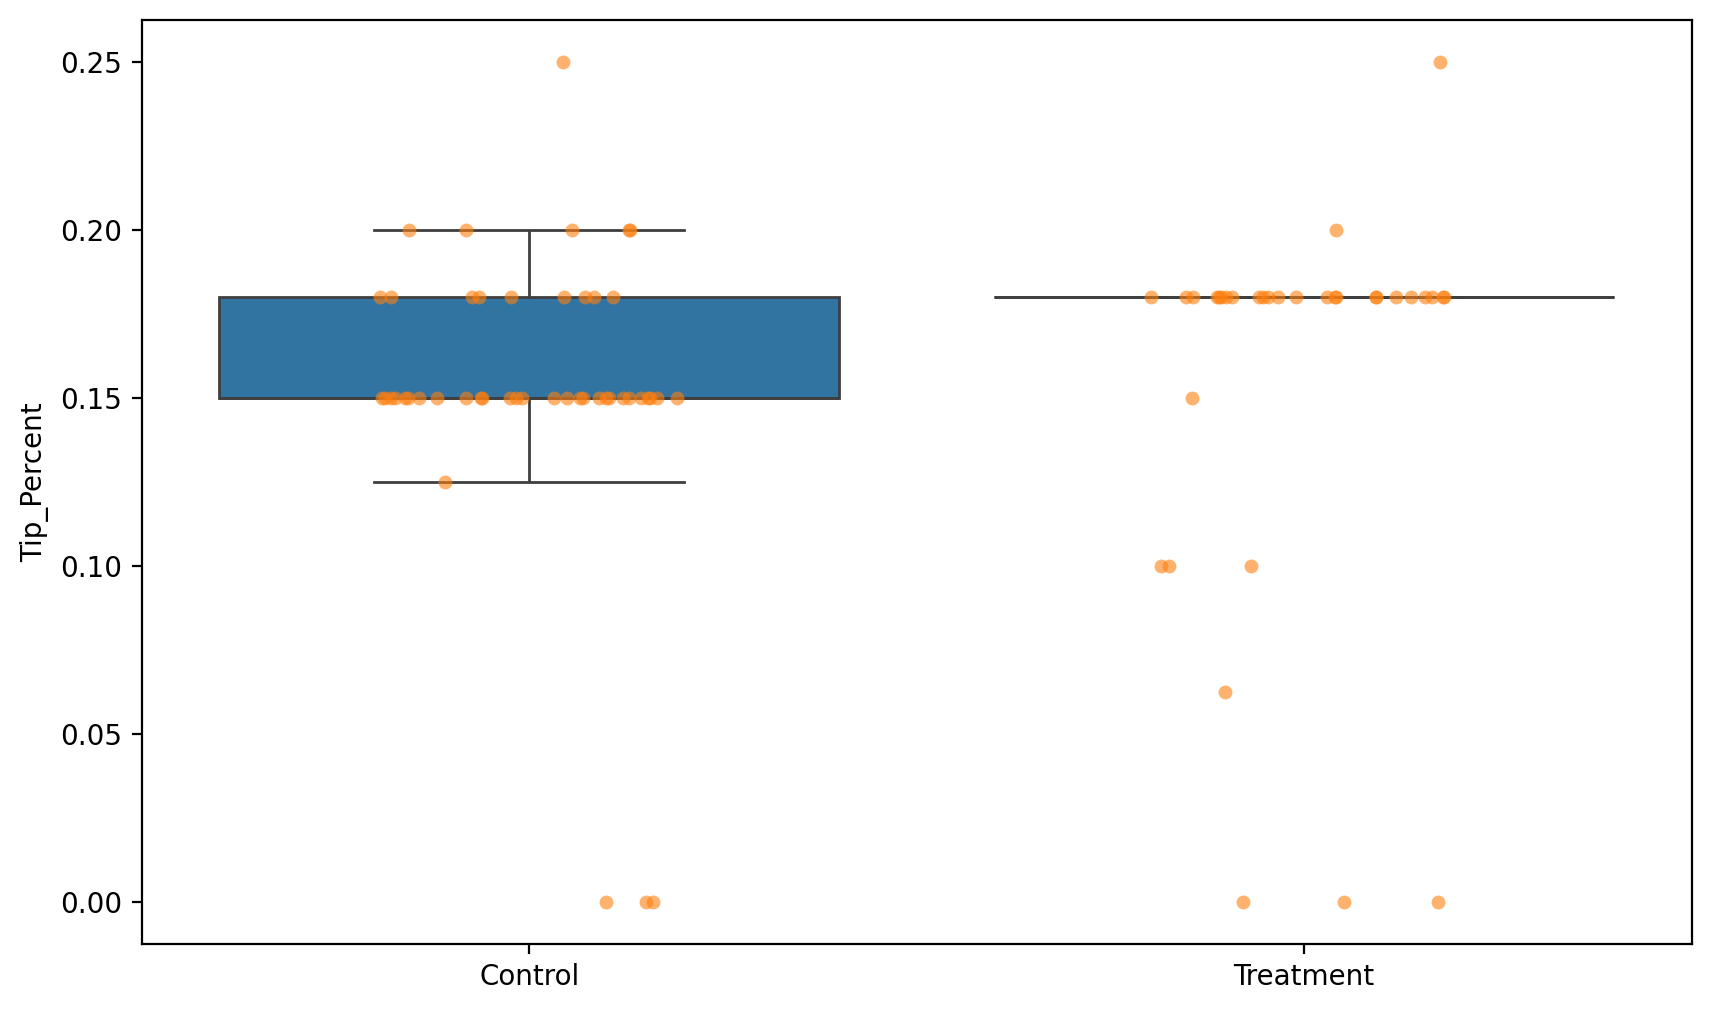

In [66]:
plt.figure(figsize=(10,6))

sns.boxplot(data=data, x="treatment_factor", y="Tip_Percent", showfliers=False)
sns.stripplot(data=data, x="treatment_factor", y="Tip_Percent", jitter=0.20, alpha=0.6)

plt.xlabel("")
plt.ylabel("Tip_Percent")
plt.show()